## TP1: Performance evaluation

In this practical session you  are going to manipulate the sklearn library.
The main goal is to analyze the performance of several methods on a binary classification task.
You will experiment with different metrics that can be used to evaluate the performance.


## Dataset loading

The breast cancer dataset is a binary classification dataset.
We are first interested to know the input dimensionality, the number of samples, the number of positive samples and the ratio of positive samples in the dataset.

In [1]:
from sklearn import datasets

dataset = datasets.load_breast_cancer()
X = dataset.data
y = dataset.target

input_dimension = len(X[0])
nb_samples = len(X)

from numpy import sum
nb_positives = sum(y)
positive_ratio = nb_positives / nb_samples
 
print("Input dimension: ", input_dimension)
print("Nb of samples in the full dataset: ", nb_samples)
print("Nb of positive samples", nb_positives)
print("Positive Ratio:", positive_ratio)


Input dimension:  30
Nb of samples in the full dataset:  569
Nb of positive samples 357
Positive Ratio: 0.6274165202108963


*Q*: What is the sample dimension? 
30

*Q*: How many samples does the dataset contain?
569

*Q*: What is the positive ratio in the dataset?
62.74%

### Dataset split
Now we are going to perform a split of the data for the evaluation. Use the train_test_split function with a test_size parameter of 0.3.

Then compute the number of samples in the train and test set, as well as their positive ratio.

In [31]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

nb_samples_train = len(X_train)
nb_samples_test = len(X_test)

nb_train_positives = sum(y_train)
nb_test_positives = sum(y_test)

train_positive_ratio = nb_train_positives / nb_samples_train
test_positive_ratio = nb_test_positives / nb_samples_test

print("Nb samples train", nb_samples_train)
print("Nb samples test", nb_samples_test)
print("Nb of positive train samples", nb_train_positives)
print("Nb of positive test samples", nb_test_positives)
print("Train Positive Ratio:", train_positive_ratio)
print("Test Positive Ratio:", test_positive_ratio)


Nb samples train 398
Nb samples test 171
Nb of positive train samples 249
Nb of positive test samples 108
Train Positive Ratio: 0.6256281407035176
Test Positive Ratio: 0.631578947368421


Q: How many samples do you have in the training set?
398

Q: How many samples in the test set?
171

Q: Are the train and test positive ratios similar ? (answer will differ depending on the random state)
Quite the same

## Train and evaluate methods

We are now going to train some classification methods on the train data.
For today we are going to use Nearest Neighbor, Logistic Regression and a Decision Tree.

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

clf_nn = KNeighborsClassifier(n_neighbors=3)
clf_tree = DecisionTreeClassifier();
clf_log = LogisticRegression(max_iter=5000);

clf_nn.fit(X_train, y_train); 
clf_tree.fit(X_train, y_train);
clf_log.fit(X_train, y_train);

Once the classifiers trained, they are ready to ```predict```. Use the prediction functions to obtain the predictions on the test data.

Sometimes it is interesting to not only look at the final prediction, but to have a look at the predicted probability. You can use the ```predict_proba``` function. From its output, for all predictions, you can keep the probability of the second class (having cancer). This is effectively performed with the python selector [:,1].

Q: For the nearest neighbor method, print the difference between the predictions and the probabilities. As you will see they are not zero. Predictions are binary, while probabilities are floats.

In [35]:
y_pred_nn = clf_nn.predict(X_test)
y_pred_tree = clf_tree.predict(X_test)
y_pred_log = clf_log.predict(X_test)

y_proba_nn = clf_nn.predict_proba(X_test)[:,1]
y_proba_tree = clf_tree.predict_proba(X_test)[:,1]
y_proba_log = clf_log.predict_proba(X_test)[:,1]

diff = y_pred_nn - y_proba_nn

print("Difference between prediction and probability in KNN", diff)


Difference between prediction and probability in KNN [-0.33333333  0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.33333333  0.33333333  0.          0.          0.33333333  0.
  0.          0.         -0.33333333  0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.         -0.33333333  0.          0.
  0.          0.          0.          0.33333333  0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.          0.          0.33333333  0.
  0.          0.          0.          0.33333333  0.          0.
  0.          0.          0.          0.          0.33333333  0.
  0.          0.33333333  0.          0.          0.          0.33333333
  0.          0.          0.          0.          0.33333333  0.
  0.          0.         -0.3

To have a sense of the difficulty of the problem it is usually helpful to evaluate simple baselines.
In this case we ask you to generate three baseline results:
- The results of a random method: use ```random.ramdom(N)``` to generate N probabilities between 0 and 1, and use ```rint``` to round them to final binary predictions.
- The results of a methods *always* classifying as "there is cancer", just use the ```ones``` method.
- The results of a methods *never* classifying as "there is cancer", just use the ```zeros``` method.

In [36]:
# create baselines
from numpy import random, zeros, ones, rint

N = nb_samples_test
y_proba_random = random.random(N)
y_pred_random = rint(y_proba_random)

y_pred_zeros = ones(N)
y_pred_ones = zeros(N)


## Metrics
Now that we have predictions and probabilities of 6 methods we are going to compare them with standard metrics.

First we want to compute their accuracy, precision, recall and f1_score. Use the ```accuracy_score```, ```precision_score```, ```recall_score``` and  ```f1_score``` to compute them.

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from numpy import rint
import numpy as np

def printMetrics(method_title, test_data, pred_data):
    print(method_title)
    TP = np.sum((test_data == 1) & (pred_data == 1))
    TN = np.sum((test_data == 0) & (pred_data == 0))
    FP = np.sum((test_data == 0) & (pred_data == 1))
    FN = np.sum((test_data == 1) & (pred_data == 0))
    accuracy = (TP + TN) / len(test_data)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    print("\tAccuracy ", accuracy)
    print("\tPrecision ", precision)
    print("\tRecall ", recall)
    print("\tF1 score", f1_score)

        
printMetrics("Nearest Neighbors:", y_test, y_pred_nn )
printMetrics("Decision Tree:", y_test, y_pred_tree)
printMetrics("Logistic Regression:", y_test, y_pred_log )
printMetrics("Random:", y_test, y_pred_random)
printMetrics("Always:", y_test, y_pred_ones )
printMetrics("Never:", y_test, y_pred_zeros )


Nearest Neighbors:
	Accuracy  0.9415204678362573
	Precision  0.9454545454545454
	Recall  0.9629629629629629
	F1 score 0.9541284403669724
Decision Tree:
	Accuracy  0.935672514619883
	Precision  0.970873786407767
	Recall  0.9259259259259259
	F1 score 0.9478672985781991
Logistic Regression:
	Accuracy  0.9766081871345029
	Precision  0.9814814814814815
	Recall  0.9814814814814815
	F1 score 0.9814814814814815
Random:
	Accuracy  0.5380116959064327
	Precision  0.6705882352941176
	Recall  0.5277777777777778
	F1 score 0.5906735751295337
Always:
	Accuracy  0.3684210526315789
	Precision  0
	Recall  0.0
	F1 score 0
Never:
	Accuracy  0.631578947368421
	Precision  0.631578947368421
	Recall  1.0
	F1 score 0.7741935483870968


Q: What do you observe from these results?

Q: Explain the value of each metrics

Q: From these results, what is your initial ranking for each methods? 

### The ROC curve

To create a ROC curve we need first to compute the false positive rate and the true positive rate.
For that we should use the probabilities (before binarization). Compute the  positive rates for all 6 methods.

In [ ]:
from sklearn.metrics import roc_curve


false_positive_rate_nn, true_positive_rate_nn, _ = roc_curve(y_test, y_pred_nn)
false_positive_rate_tree, true_positive_rate_tree, _ = roc_curve(y_test, y_pred_tree)
false_positive_rate_log, true_positive_rate_log, _ = roc_curve(y_test, y_pred_log)
false_positive_rate_random, true_positive_rate_random, _ = roc_curve(y_test, y_pred_random)
false_positive_rate_zeros, true_positive_rate_zeros, _ = roc_curve(y_test, y_pred_zeros)
false_positive_rate_ones, true_positive_rate_ones, _ = roc_curve(y_test, y_pred_ones)


To plot a ROC curve you need to plot the False positive rate against the True positive rate.
Complete the function definition and give the proper arguments to do the plots.

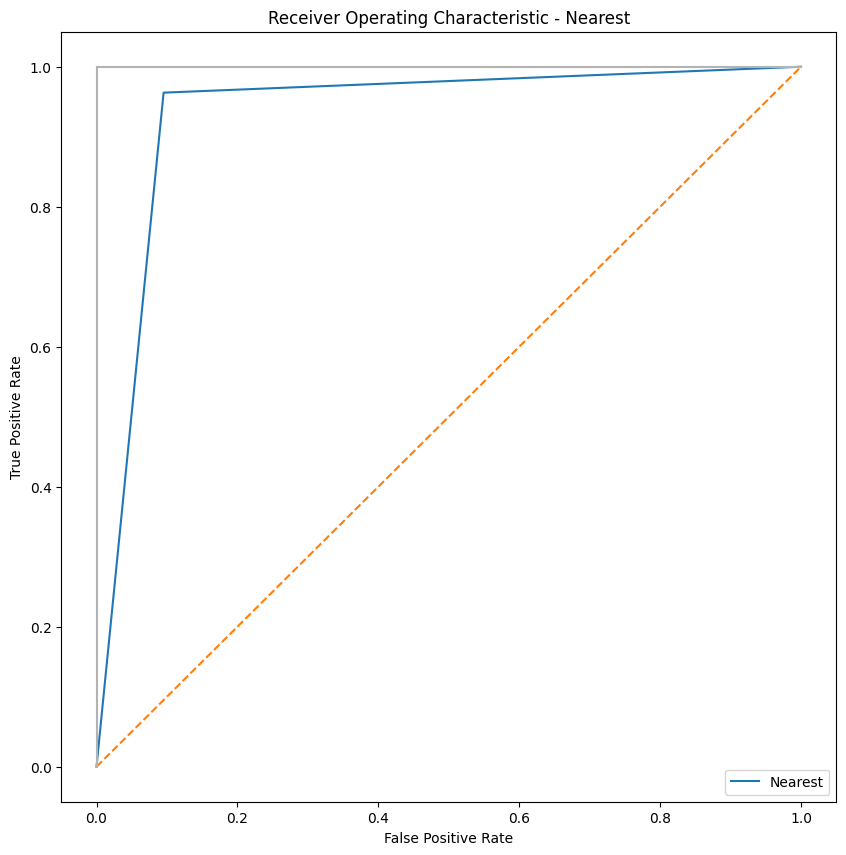

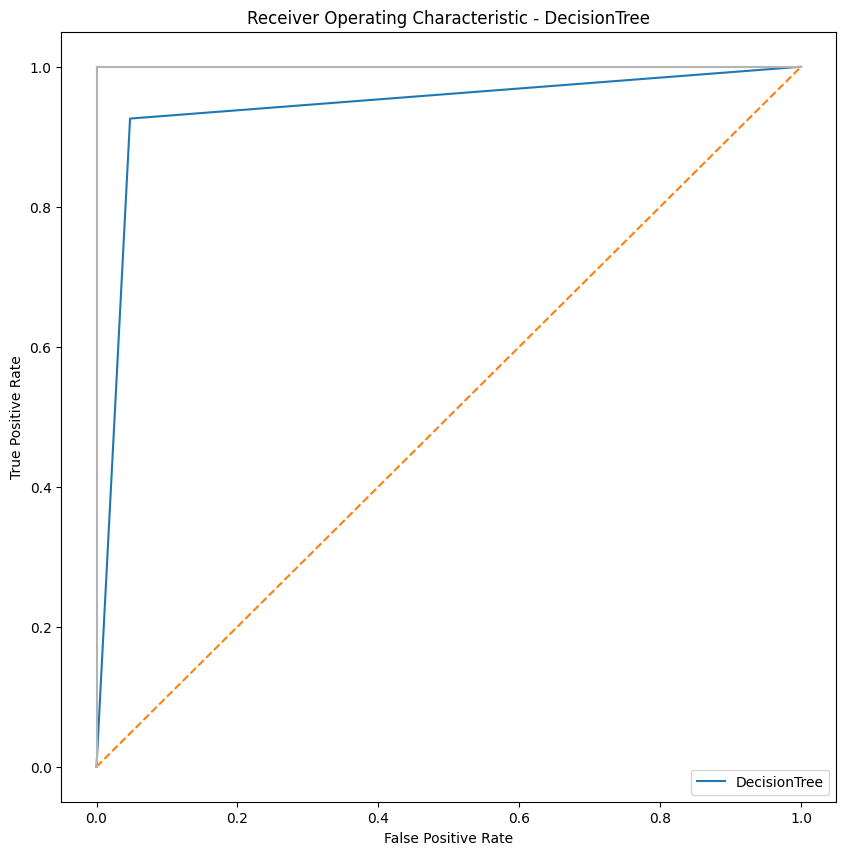

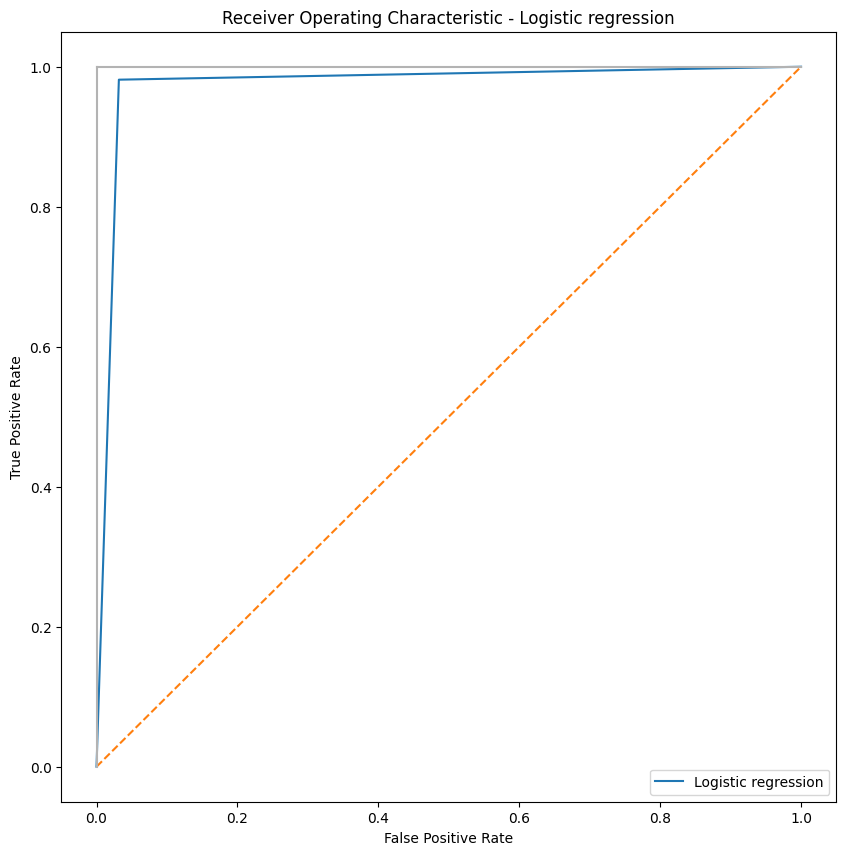

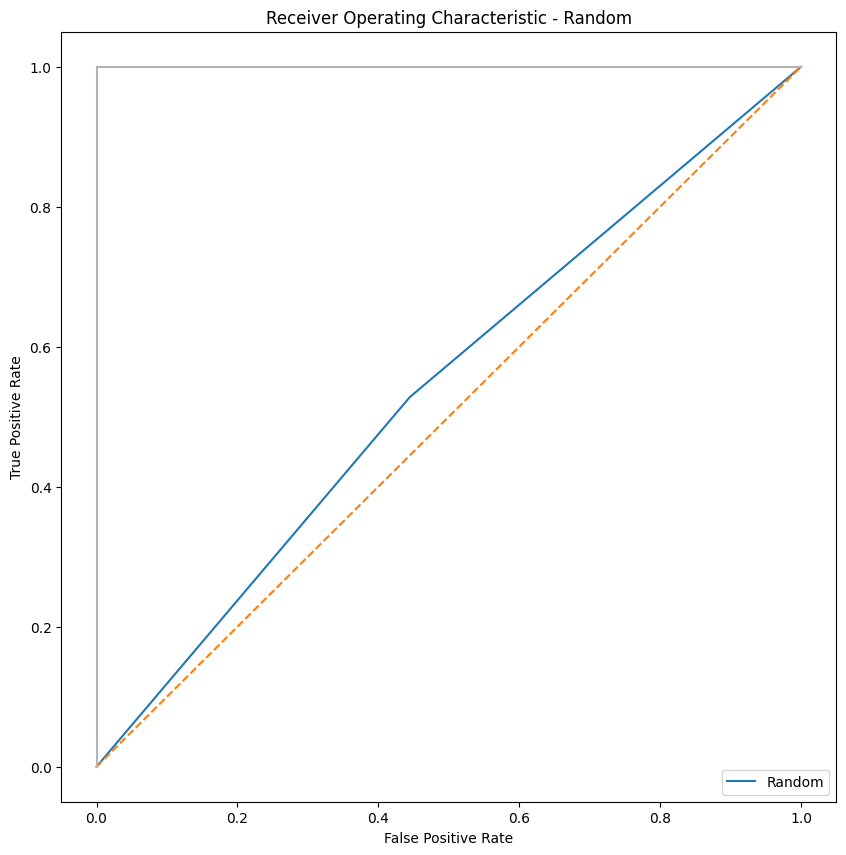

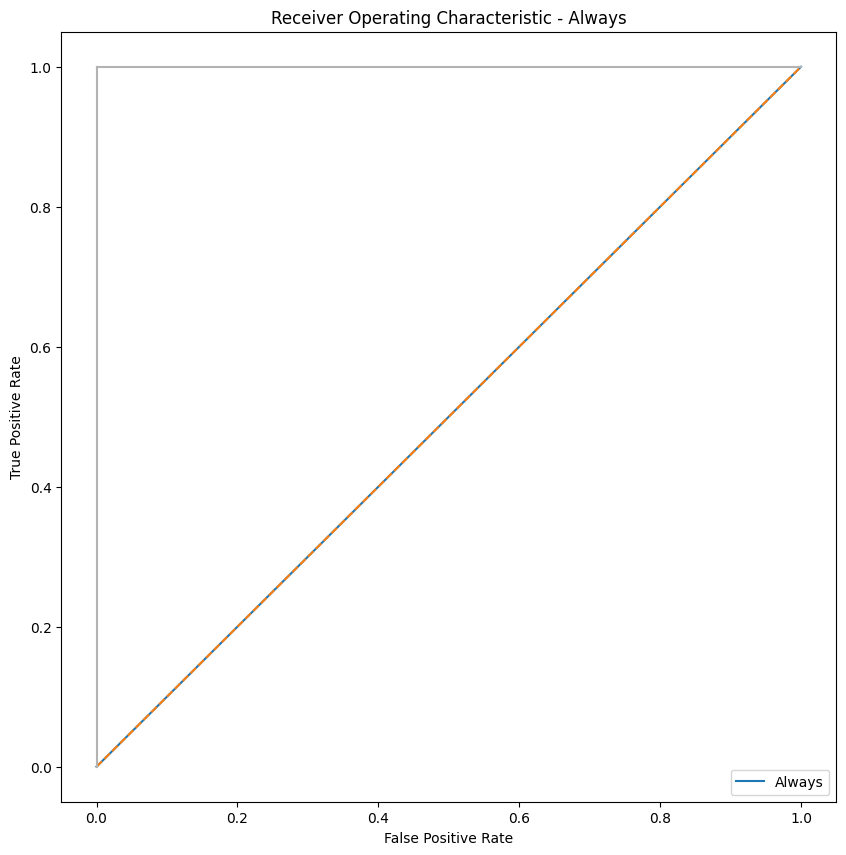

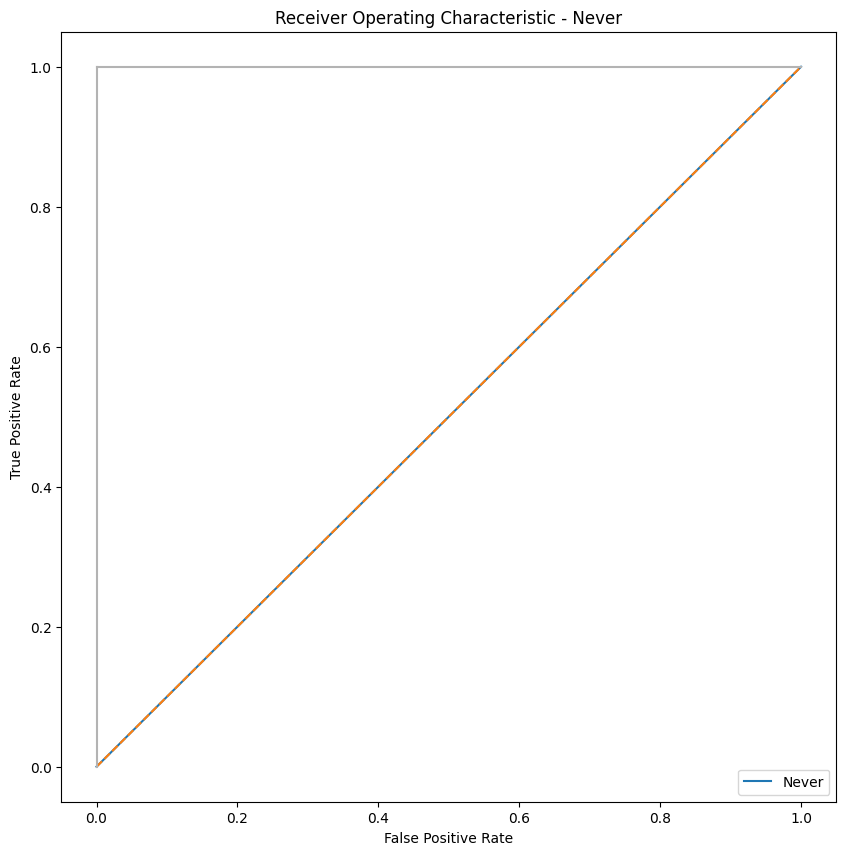

In [ ]:
import matplotlib.pyplot as plt

def plotROC(title, FP, TP):
    plt.subplots(1, figsize=(10,10))
    plt.title('Receiver Operating Characteristic - ' + title)
    plt.plot(FP, TP)
    plt.plot([0, 1], ls="--") # This draws the diagonal
    plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7") # This draws the "perfect" score
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

plotROC("Nearest", false_positive_rate_nn, true_positive_rate_nn); # TODO add FP and TP
plotROC("DecisionTree", false_positive_rate_tree, true_positive_rate_tree); # TODO add FP and TP
plotROC("Logistic regression", false_positive_rate_log, true_positive_rate_log);
plotROC("Random", false_positive_rate_random, true_positive_rate_random); # TODO add FP and TP
plotROC("Always", false_positive_rate_ones, true_positive_rate_ones); # TODO add FP and TP
plotROC("Never", false_positive_rate_zeros, true_positive_rate_zeros); # TODO add FP and TP


Q: Compare the curves. What do you see?

Q: Particularly, compare the "Always cancer" and "Never cancer" curves. Why do you get these curves? Discuss their similarities and or differences.

Q: Would your preliminary ranking of the methods change after seeing these curves? Explain why or why not.

For a better comparison you can plot all curves in the same plot.
Use the parameter ```label='Data label'``` in the plot function to know which one is each and the ```plot.legend(loc="lower right")``` to show the legend.

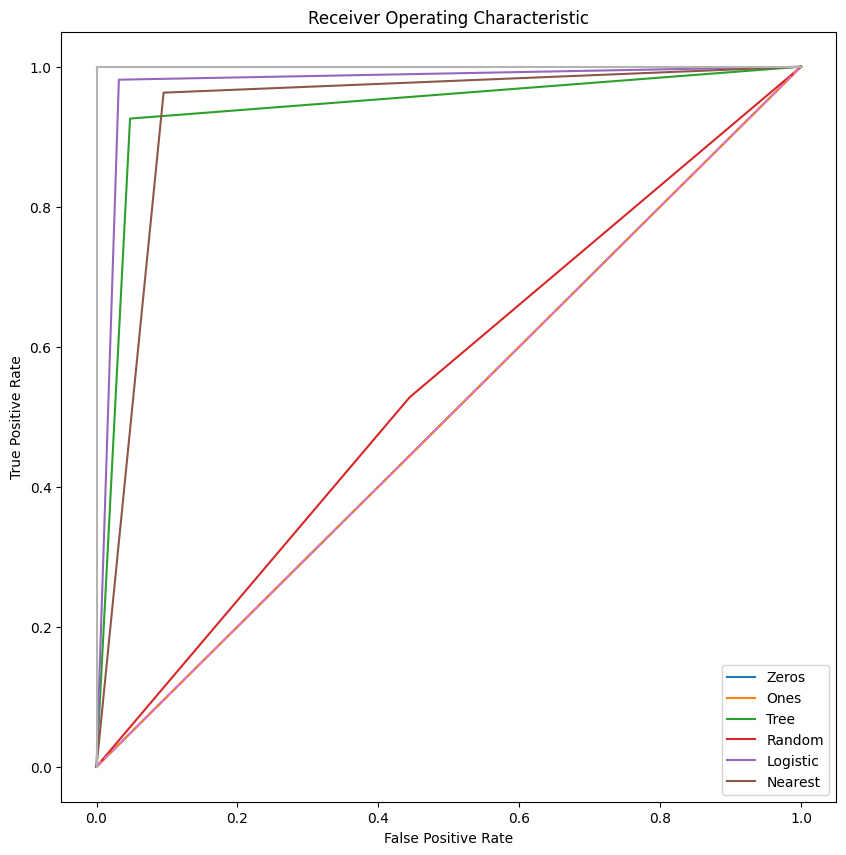

In [61]:
plt.subplots(1, figsize=(10,10))
plt.title('Receiver Operating Characteristic')

plt.plot(false_positive_rate_zeros, true_positive_rate_zeros, label="Zeros"); # TODO
plt.plot(false_positive_rate_ones, true_positive_rate_ones,  label="Ones"); # TODO
plt.plot(false_positive_rate_tree, true_positive_rate_tree,  label="Tree"); # TODO
plt.plot(false_positive_rate_random, true_positive_rate_random,  label="Random"); # TODO
plt.plot(false_positive_rate_log, true_positive_rate_log,  label="Logistic"); # TODO
plt.plot(false_positive_rate_nn, true_positive_rate_nn,  label="Nearest"); # TODO

plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc = "lower right")
plt.show()



To compute the Roc Area Under Curve (AUC) score you can use the function ```roc_auc_score```

In [63]:
from sklearn.metrics import roc_auc_score

print('roc_auc_score for Nearest: ', roc_auc_score(y_test, y_pred_nn)) # TODO
print('roc_auc_score for DecisionTree: ', roc_auc_score(y_test, y_pred_tree)) # TODO
print('roc_auc_score for Logistic Regression: ', roc_auc_score(y_test, y_pred_log)) # TODO
print('roc_auc_score for Random Guessing: ', roc_auc_score(y_test, y_pred_random)) # TODO
print('roc_auc_score for Always No Cancer: ', roc_auc_score(y_test, y_pred_zeros))
print('roc_auc_score for Always Cancer: ', roc_auc_score(y_test, y_pred_ones))


roc_auc_score for Nearest:  0.9338624338624338
roc_auc_score for DecisionTree:  0.9391534391534391
roc_auc_score for Logistic Regression:  0.9748677248677248
roc_auc_score for Random Guessing:  0.5416666666666666
roc_auc_score for Always No Cancer:  0.5
roc_auc_score for Always Cancer:  0.5


Q: Do you have a strong preference on which method you would use? Why?

### Rerunning the process

Save the current results (screenshot or write down the roc auc scores), then go back to the beginning of the notebook and rerun the script.

Q: Do you get the same numeric results? Why? How to get some control for this variability?

## Cross validation

Cross validation is a way to evaluate on the full dataset.
The sklearn library implements the ```KFold``` function that allows to create K splits for train and test.

Use it to obtain splits, plot the positive ratio in each split in the train and in the test and their difference.

Q: What do you observe?



In [64]:
from sklearn.model_selection import KFold

n_splits = 10

kfold = KFold(n_splits)
kfold_splits = kfold.split(X)


# each split contains indices for the train and test data
for train_indices, test_indices in kfold_splits:
    # select the data for the fold
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # compute ratio of positive examples
    nb_train = len(y_train)
    train_positive = (y_train == 1).sum()
    train_ratio = train_positive/nb_train
    
    nb_test = len(y_test)
    test_positive = (y_test == 1).sum()
    test_ratio = test_positive/nb_test
    
    print("\nTrain positive Ratio:", train_ratio)
    print("Test postivie Ratio:", test_ratio)
    print("Difference:", train_ratio - test_ratio)



Train positive Ratio: 0.67578125
Test postivie Ratio: 0.19298245614035087
Difference: 0.48279879385964913

Train positive Ratio: 0.62890625
Test postivie Ratio: 0.6140350877192983
Difference: 0.014871162280701733

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.640625
Test postivie Ratio: 0.5087719298245614
Difference: 0.13185307017543857

Train positive Ratio: 0.640625
Test postivie Ratio: 0.5087719298245614
Difference: 0.13185307017543857

Train positive Ratio: 0.609375
Test postivie Ratio: 0.7894736842105263
Difference: -0.18009868421052633

Train positive Ratio: 0.6171875
Test postivie Ratio: 0.7192982456140351
Difference: -0.1021107456140351

Train positive Ratio: 0.611328125
Test postivie Ratio: 0.7719298245614035
Difference: -0.16060169956140347

Train positive Ratio: 0.611328125
Test postivie Ratio: 0.7719298245614035
Difference: -0.16060169956140347

Train positive Ratio: 0.6120857699805068
Te

One way to ensure the same positive rate in the splits is to use Stratified K Fold cross validation.
Adapt the previous code to use ```StratifiedKFold``` and compare the results.

In [66]:
from sklearn.model_selection import StratifiedKFold

n_splits=10

kfold = StratifiedKFold(n_splits)
kfold_splits = kfold.split(X, y)


# each split contains indices for the train and test data
for train_indices, test_indices in kfold_splits:
    # select the data for the fold
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]
    
    # compute ratio of positive examples
    nb_train = len(y_train)
    train_positive = (y_train == 1).sum()
    train_ratio = train_positive / nb_train
    
    nb_test = len(y_test)
    test_positive = (y_test == 1).sum()
    test_ratio = test_positive / nb_test
    
    print("\nTrain positive Ratio:", train_ratio)
    print("Test postivie Ratio:", test_ratio)
    print("Difference:", train_ratio - test_ratio)
    


Train positive Ratio: 0.62890625
Test postivie Ratio: 0.6140350877192983
Difference: 0.014871162280701733

Train positive Ratio: 0.62890625
Test postivie Ratio: 0.6140350877192983
Difference: 0.014871162280701733

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.626953125
Test postivie Ratio: 0.631578947368421
Difference: -0.004625822368421018

Train positive Ratio: 0.62768

Q: Compare and discuss the differences between the ```KFold``` and ```StratifiedKFold``` methods.